# Tutorial for wind process module

References:
- Maki, A., Maruyama, Y., Dostal, L. et al. Practical method for evaluating wind influence on autonomous ship operations. J Mar Sci Technol 27, 1302-1313 (2022). https://doi.org/10.1007/s00773-022-00901-w


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyshipsim
from utils import font_setting

font_setting()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
ImportError: Import of esso_osaka_3m's f2py mpdule failed.
ImportError: Import of takaoki_3m's f2py mpdule failed.
ImportError: Import of pcc_3m's f2py module failed.
ImportError: Import of flap3rd's f2py module failed.


### Random wind (U = 10.0 m/s)

------------------ Simulator Info ------------------
Given objects:
    RandomWind:
        State variables
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        External State variables
        Observation variables
            hat_true_wind_speed [m/s]: [0.0, inf]
            hat_true_wind_direction [rad]: [0.0, 6.283185307179586]
The state variables that need to be given are as follows:
----------------------------------------------------


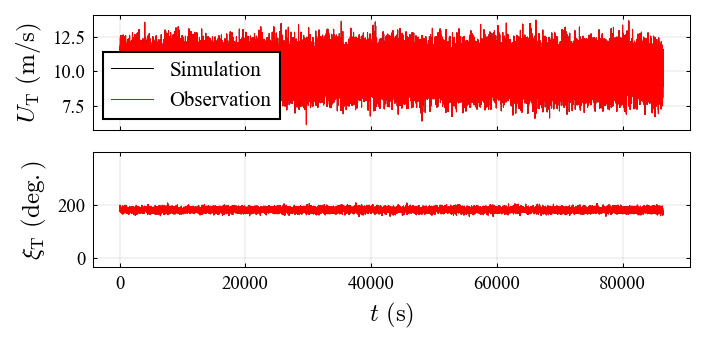

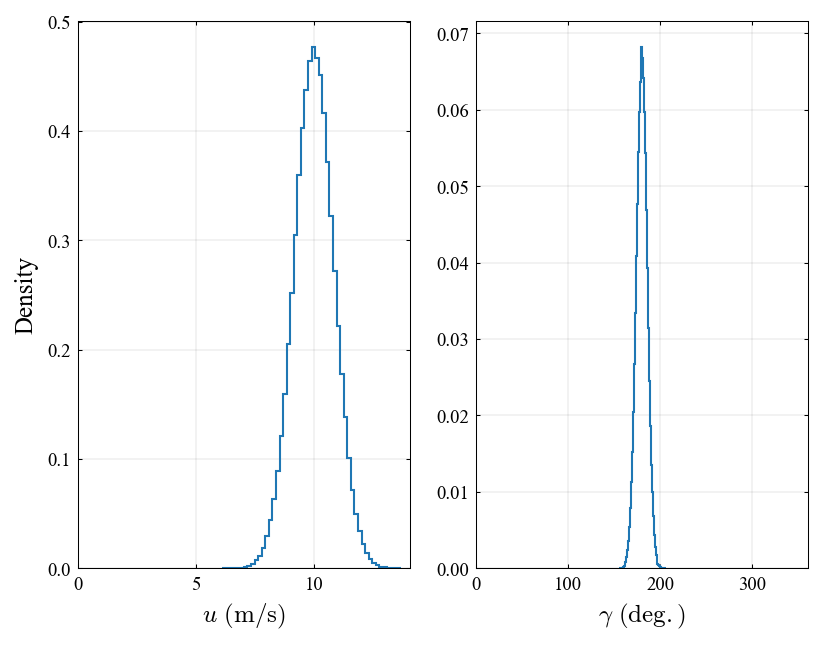

In [2]:
# シミュレータを生成
sim = pyshipsim.Simulator(
    pyshipsim.RandomWind(),
    dt_act=60*60*24,
    dt_sim=0.1,
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))
# get_info()で確認した状態の順番に初期状態を設定
true_wind_speed, true_wind_direction = 10.0, np.pi
init_states = {
    "RandomWind": [true_wind_speed, true_wind_direction],
}
# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
sim.step()

sim.plot_timeseries(path="./log/tutorial_wind/")
sim.to_csv(path="./log/tutorial_wind/log.csv")

df = sim.get_log()
fig, axes = plt.subplots(1, 2)
kwargs = {"bins":50, "histtype":"step", "density":True}
axes[0].hist(df["true_wind_speed [m/s]"], **kwargs)
axes[1].hist(np.rad2deg(df["true_wind_direction [rad]"])%(360), **kwargs)
axes[0].set_xlabel("$u \\ \\mathrm{(m/s)}$")
axes[1].set_xlabel("$\\gamma \\ \\mathrm{(deg.)}$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(left=0)
axes[1].set_xlim(0, 360)
plt.show()

### Random wind (U = 0.1 m/s)

------------------ Simulator Info ------------------
Given objects:
    RandomWind:
        State variables
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        External State variables
        Observation variables
            hat_true_wind_speed [m/s]: [0.0, inf]
            hat_true_wind_direction [rad]: [0.0, 6.283185307179586]
The state variables that need to be given are as follows:
----------------------------------------------------


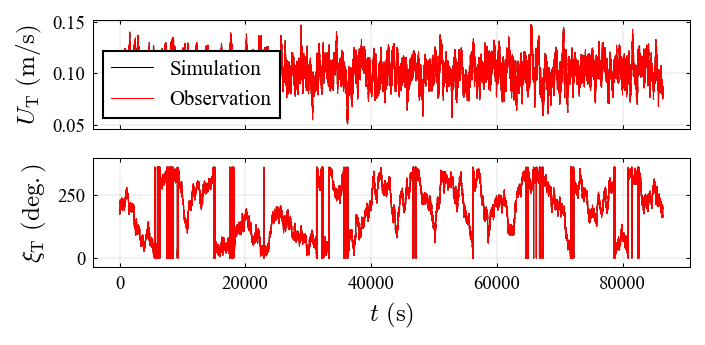

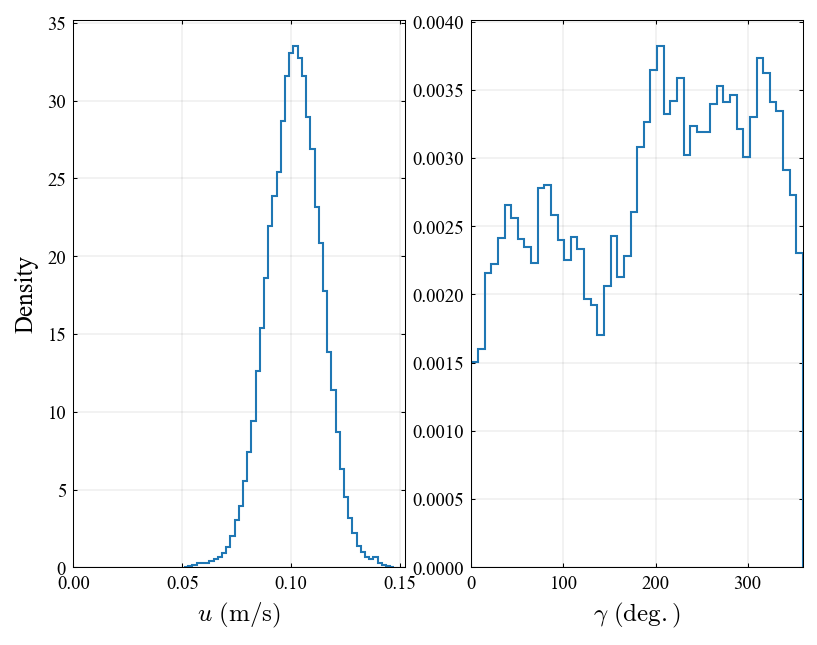

In [3]:
# シミュレータを生成
sim = pyshipsim.Simulator(
    pyshipsim.RandomWind(),
    dt_act=60*60*24,
    dt_sim=0.1,
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))
# get_info()で確認した状態の順番に初期状態を設定
true_wind_speed, true_wind_direction = 0.1, np.pi
init_states = {
    "RandomWind": [true_wind_speed, true_wind_direction],
}
# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
sim.step()

sim.plot_timeseries(path="./log/tutorial_wind/")
sim.to_csv(path="./log/tutorial_wind/log.csv")

df = sim.get_log()
fig, axes = plt.subplots(1, 2)
kwargs = {"bins":50, "histtype":"step", "density":True}
axes[0].hist(df["true_wind_speed [m/s]"], **kwargs)
axes[1].hist(np.rad2deg(df["true_wind_direction [rad]"])%(360), **kwargs)
axes[0].set_xlabel("$u \\ \\mathrm{(m/s)}$")
axes[1].set_xlabel("$\\gamma \\ \\mathrm{(deg.)}$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(left=0)
axes[1].set_xlim(0, 360)
plt.show()

### Stationary wind (U = 1.0 m/s)

------------------ Simulator Info ------------------
Given objects:
    StationaryWind:
        State variables
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        External State variables
        Observation variables
            hat_true_wind_speed [m/s]: [0.0, inf]
            hat_true_wind_direction [rad]: [0.0, 6.283185307179586]
The state variables that need to be given are as follows:
----------------------------------------------------


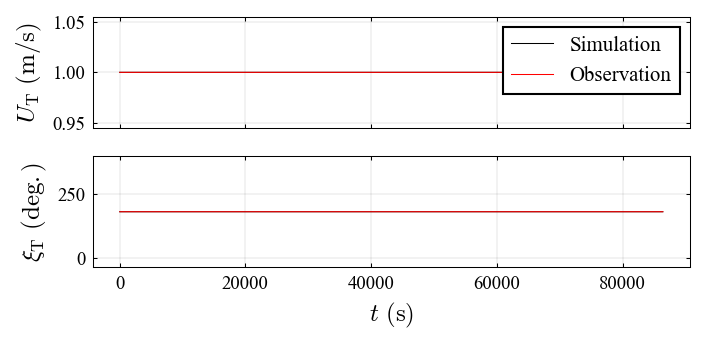

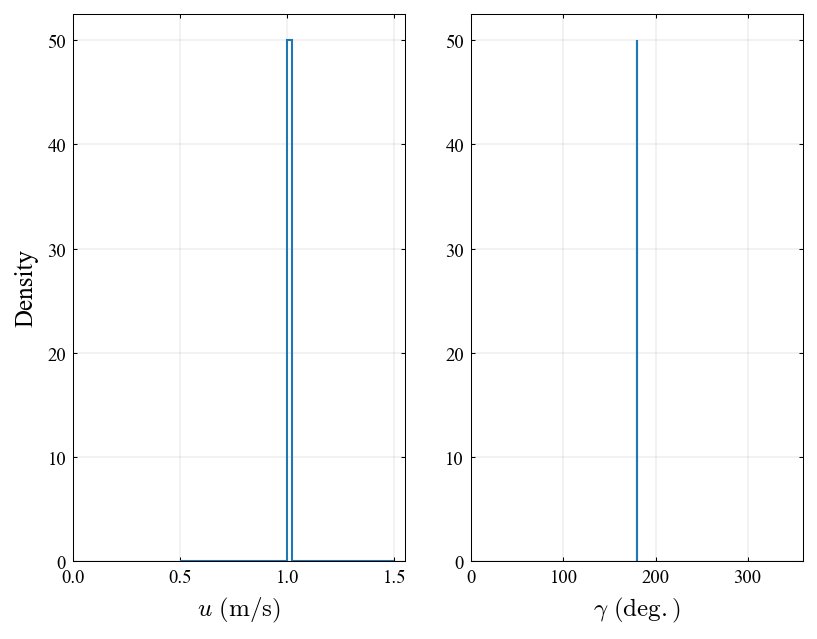

In [4]:
# シミュレータを生成
sim = pyshipsim.Simulator(
    pyshipsim.StationaryWind(),
    dt_act=60*60*24,
    dt_sim=0.1,
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))
# get_info()で確認した状態の順番に初期状態を設定
true_wind_speed, true_wind_direction = 1.0, np.pi
init_states = {
    "StationaryWind": [true_wind_speed, true_wind_direction],
}
# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
sim.step()

sim.plot_timeseries(path="./log/tutorial_wind/")
sim.to_csv(path="./log/tutorial_wind/log.csv")

df = sim.get_log()
fig, axes = plt.subplots(1, 2)
kwargs = {"bins":50, "histtype":"step", "density":True}
axes[0].hist(df["true_wind_speed [m/s]"], **kwargs)
axes[1].hist(np.rad2deg(df["true_wind_direction [rad]"])%(360), **kwargs)
axes[0].set_xlabel("$u \\ \\mathrm{(m/s)}$")
axes[1].set_xlabel("$\\gamma \\ \\mathrm{(deg.)}$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(left=0)
axes[1].set_xlim(0, 360)
plt.show()